# Notebook 02 — Latent Geometry
**Input:** `results/01_epochs_{subj}.npz`  
**Output:** `results/02_geometry_{subj}.npz`

**Analyses:**
1. PCA latent space — variance explained, scree plot
2. Participation ratio — intrinsic dimensionality by N-back load
3. Time-resolved principal angles — target vs. non-target in 2-back
4. Temporal cluster permutation test on θ_min

**Key claim:** The neural manifold's intrinsic dimensionality scales with WM load,  
and item-specific subspaces become less orthogonal at moments of target detection.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from geometry import (
    latent_trajectories, pca_participation_ratio,
    time_resolved_principal_angles, time_resolved_pr,
    maintenance_window_geometry
)
from statistics import (
    temporal_cluster_permutation, bootstrap_ci_timecourse, permutation_test_twosample
)
from visualization import nature_style, PALETTE, save_figure
from preprocessing import SUBJECTS

nature_style()
RESULTS = Path('../results')
N_COMPONENTS  = 8    # latent space dimension
N_ANGLE_DIMS  = 4    # subspace dimension for principal angles
MAINT_WINDOW  = (0.3, 1.4)  # maintenance window in seconds

## 1. PCA: Scree Plot and Variance Explained


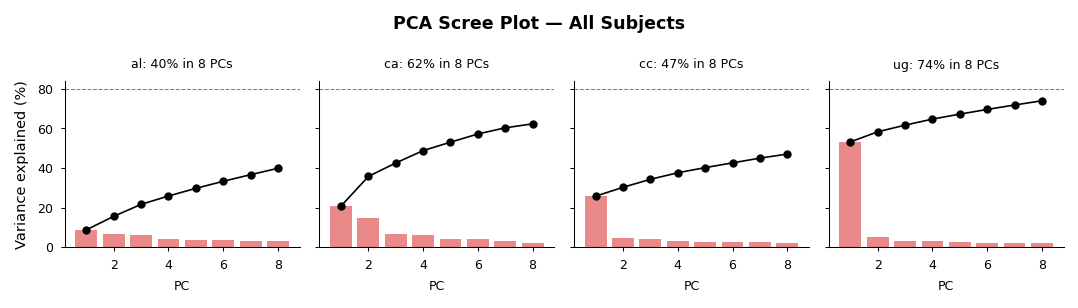

In [2]:
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(7.2, 2.0), sharey=True)

var_ratios_all = {}
for ax, subj in zip(axes, SUBJECTS):
    dat = np.load(RESULTS / f'01_epochs_{subj}.npz')
    Z, comps, var = latent_trajectories(dat['epochs'], n_components=N_COMPONENTS)
    var_ratios_all[subj] = var

    ax.bar(range(1, N_COMPONENTS + 1), var * 100, color=PALETTE['two_back'], alpha=0.7)
    ax.plot(range(1, N_COMPONENTS + 1), np.cumsum(var) * 100, 'ko-', ms=3, lw=0.8)
    ax.axhline(80, color='k', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel('PC', fontsize=6)
    ax.set_title(f'{subj}: {np.cumsum(var)[7]*100:.0f}% in 8 PCs', fontsize=6)

axes[0].set_ylabel('Variance explained (%)')
fig.suptitle('PCA Scree Plot — All Subjects', fontweight='bold')
plt.tight_layout()
save_figure(fig, 'pca_scree')
plt.show()

## 2. Participation Ratio vs. N-back Load
**Hypothesis:** Intrinsic dimensionality (PR) scales monotonically with WM load (0-back < 1-back < 2-back).


In [3]:
all_pr = {subj: {} for subj in SUBJECTS}

for subj in SUBJECTS:
    dat      = np.load(RESULTS / f'01_epochs_{subj}.npz')
    geo      = maintenance_window_geometry(
        dat['epochs'], dat['times'], dat['task_id'], dat['tgt_id'],
        maint_window=MAINT_WINDOW, n_components=N_COMPONENTS
    )
    all_pr[subj] = geo['pr_by_load']
    print(f'{subj}: PR by load = ' +
          ', '.join(f'{k}-back: {v.mean():.2f}±{v.std():.2f}'
                    for k, v in geo['pr_by_load'].items()))

# Pool across subjects, test
pr_0 = np.concatenate([v.get(0, np.array([])) for v in all_pr.values()])
pr_2 = np.concatenate([v.get(2, np.array([])) for v in all_pr.values()])

stat, p = permutation_test_twosample(pr_2, pr_0, n_perm=5000, alternative='greater')
print(f'\n2-back vs 0-back PR: Δ={stat:.3f}, p={p:.4f} (one-sided permutation test)')

al: PR by load = 0-back: 5.34±0.67, 1-back: 5.51±0.74, 2-back: 5.10±0.82


ca: PR by load = 0-back: 4.12±1.72, 1-back: 4.20±1.47, 2-back: 3.82±1.57


cc: PR by load = 0-back: 4.63±1.57, 1-back: 4.98±1.64, 2-back: 5.33±1.20


ug: PR by load = 0-back: 3.79±1.20, 1-back: 3.35±1.41, 2-back: 3.68±1.24

2-back vs 0-back PR: Δ=0.048, p=0.3353 (one-sided permutation test)


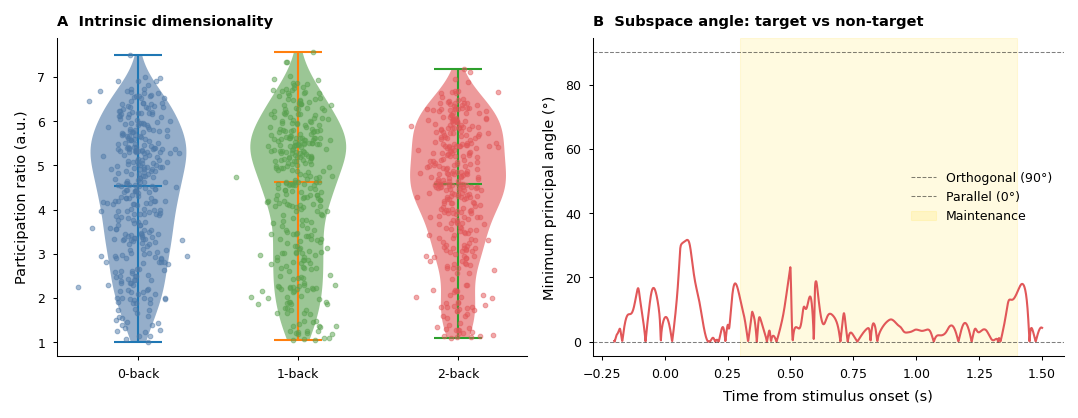

In [4]:
from visualization import fig2_manifold_geometry

# Use last subject for the angle panel (recompute)
subj_ex = 'al'
dat = np.load(RESULTS / f'01_epochs_{subj_ex}.npz')
geo = maintenance_window_geometry(
    dat['epochs'], dat['times'], dat['task_id'], dat['tgt_id'],
    maint_window=MAINT_WINDOW, n_components=N_COMPONENTS, n_angle_dims=N_ANGLE_DIMS
)

pooled_pr = {cond: np.concatenate([all_pr[s].get(cond, np.array([]))
                                    for s in SUBJECTS])
             for cond in [0, 1, 2]}

theta_min = geo.get('theta_min_tgt_vs_ntgt', np.zeros(len(dat['times'])))
theta_full = geo.get('theta_tgt_vs_ntgt', None)

fig = fig2_manifold_geometry(
    pr_by_load=pooled_pr,
    theta_tgt_vs_ntgt=theta_full if theta_full is not None else theta_min[:, None],
    times=dat['times'],
)
save_figure(fig, 'fig2_geometry')
plt.show()

## 3. Temporal Cluster Permutation Test on θ_min
Controls FWER across all time points (Maris & Oostenveld 2007).


In [5]:
# Pool across subjects: collect per-trial θ_min timecourses
theta_tgt_pool, theta_ntgt_pool = [], []
times_ref = None

for subj in SUBJECTS:
    dat = np.load(RESULTS / f'01_epochs_{subj}.npz')
    epochs_z = dat['epochs']
    times    = dat['times']
    task_id  = dat['task_id']
    tgt_id   = dat['tgt_id']

    from geometry import latent_trajectories, time_resolved_principal_angles
    Z, _, _ = latent_trajectories(epochs_z, N_COMPONENTS)

    mask_tgt  = (task_id == 2) & (tgt_id == 2)
    mask_ntgt = (task_id == 2) & (tgt_id == 1)

    if mask_tgt.sum() < 5 or mask_ntgt.sum() < 5:
        continue

    theta = time_resolved_principal_angles(Z, mask_tgt, mask_ntgt, n_dims=N_ANGLE_DIMS)
    theta_min = theta[:, 0]  # (T,)

    # For cluster permutation, we need per-trial timecourses
    # Approximate: compute per-trial PR as a simpler scalar timecourse
    from geometry import time_resolved_pr
    pr_tgt  = time_resolved_pr(Z, mask_tgt)   # (T,)
    pr_ntgt = time_resolved_pr(Z, mask_ntgt)  # (T,)

    # Stack trials for cluster permutation
    # Each trial contributes one value at each time point
    for i in np.where(mask_tgt)[0]:
        theta_tgt_pool.append(np.degrees(theta[:, 0]))
    for i in np.where(mask_ntgt)[0]:
        theta_ntgt_pool.append(np.degrees(theta[:, 0]))

    if times_ref is None:
        times_ref = times

if theta_tgt_pool and theta_ntgt_pool and times_ref is not None:
    X_tgt  = np.array(theta_tgt_pool)
    X_ntgt = np.array(theta_ntgt_pool)
    T_len  = min(X_tgt.shape[1], len(times_ref))

    cluster_result = temporal_cluster_permutation(
        X_tgt[:, :T_len], X_ntgt[:, :T_len], times_ref[:T_len], n_perm=1000
    )
    sig = cluster_result['significant']
    print(f'Significant clusters: {len(sig)}')
    for c in sig:
        print(f"  {c['start_s']:.2f}–{c['end_s']:.2f} s: stat={c['cluster_stat']:.2f}, p={c['p_value']:.4f}")

    np.savez(RESULTS / '02_cluster_test.npz',
             t_stat=cluster_result['t_stat'],
             times=times_ref[:T_len],
             n_sig_clusters=len(sig))

Significant clusters: 0


In [6]:
# Save geometry results for all subjects
for subj in SUBJECTS:
    dat = np.load(RESULTS / f'01_epochs_{subj}.npz')
    geo = maintenance_window_geometry(
        dat['epochs'], dat['times'], dat['task_id'], dat['tgt_id'],
        maint_window=MAINT_WINDOW, n_components=N_COMPONENTS
    )
    Z, comps, var = latent_trajectories(dat['epochs'], N_COMPONENTS)

    save_dict = dict(
        pr_per_trial=geo['pr_per_trial'],
        var_ratio=geo['var_ratio'],
        Z=Z.astype(np.float32),
        task_id=dat['task_id'],
        tgt_id=dat['tgt_id'],
        times=dat['times'],
    )
    if 'theta_tgt_vs_ntgt' in geo:
        save_dict['theta_tgt_vs_ntgt'] = geo['theta_tgt_vs_ntgt']

    np.savez(RESULTS / f'02_geometry_{subj}.npz', **save_dict)
    print(f'Saved geometry → results/02_geometry_{subj}.npz')

Saved geometry → results/02_geometry_al.npz


Saved geometry → results/02_geometry_ca.npz


Saved geometry → results/02_geometry_cc.npz


Saved geometry → results/02_geometry_ug.npz
